<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/Tutorial_pyAgrum_Causalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de pyAgrum: modelado probabilístico y causalidad

**Objetivo de este notebook:**

1. Introducir `pyAgrum`, una librería de Python (basada en `aGrUM`, C++) para construir, visualizar y hacer inferencia con **redes bayesianas**.
2. Reproducir el ejemplo clásico del **pasto mojado** (*wet grass*), tomado del [tutorial oficial de pyAgrum](https://pyagrum.readthedocs.io/en/latest/notebooks/01-Tutorial_pyAgrum.html), para ilustrar los conceptos fundamentales: variables, arcos, tablas de probabilidad condicional (CPT) e inferencia.
3. Dar el salto de la **inferencia probabilística** a la **inferencia causal**: mostrar por qué "observar" no es lo mismo que "intervenir" (`do`-calculus), usando el módulo `pyagrum.causal`.
4. Simular una **base de datos pequeña** en un contexto distinto (hábitos de estudio y rendimiento académico) y mostrar cómo `pyAgrum` puede **aprender la estructura de un DAG a partir de datos observacionales**, junto con las limitaciones de ese aprendizaje.

Este notebook está optimizado para ejecutarse directamente en **Google Colab** (sin instalaciones previas).

## 0. Instalación (en Colab)

`pyAgrum` no viene preinstalado en Colab. Desde la versión 2.0.0, el paquete se instala y se importa en minúsculas: `pip install pyagrum` / `import pyagrum as gum`.

In [ ]:
# Si estás en Google Colab
try:
    import pyagrum as gum
    print("pyAgrum ya está instalado. Versión:", gum.__version__)
except ImportError:
    !pip install pyagrum --quiet
    import pyagrum as gum
    print("pyAgrum instalado. Versión:", gum.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.4 MB/s eta 0:00:00
pyAgrum instalado. Versión: 2.3.2


In [ ]:
# Librerías del ecosistema pyAgrum que usaremos a lo largo del notebook
import pyagrum as gum
import pyagrum.lib.notebook as gnb   # utilidades de visualización para notebooks
import pyagrum.causal as csl         # módulo de inferencia causal (do-calculus)
import pyagrum.causal.notebook as cslnb  # utilidades de visualización para el módulo causal

# Librerías estándar para la parte de simulación y aprendizaje de estructura
import numpy as np
import pandas as pd

np.random.seed(42)

print("Todo listo. Versión de pyAgrum:", gum.__version__)


Todo listo. Versión de pyAgrum: 2.3.2


## 1. Conceptos fundamentales

Una **red bayesiana (BN)** es un modelo gráfico probabilístico compuesto por:

- Un **grafo acíclico dirigido (DAG)**: los nodos son variables aleatorias y los arcos representan dependencias probabilísticas directas.
- Un conjunto de **tablas de probabilidad condicional (CPT)**: cada nodo tiene una CPT que describe $P(\text{nodo} \mid \text{padres del nodo})$.

Gracias a la estructura del DAG, la distribución conjunta se factoriza como:

$$P(X_1, \dots, X_n) = \prod_{i=1}^n P(X_i \mid \text{padres}(X_i))$$

Esto es lo que hace que las redes bayesianas sean tratables incluso con muchas variables: en vez de guardar la tabla conjunta completa, basta con guardar CPTs locales, mucho más pequeñas.

En `pyAgrum`, la clase central es `gum.BayesNet`. Vamos a construir paso a paso el ejemplo clásico del **pasto mojado**.

## 2. El ejemplo del pasto mojado (*wet grass*)

Este es el ejemplo introductorio del [tutorial de la documetación de pyAgrum](https://pyagrum.readthedocs.io/en/latest/notebooks/01-Tutorial_pyAgrum.html). La historia es la siguiente:

- Si está **nublado**, es más probable que **llueva** y también cambia la probabilidad de que alguien active el **aspersor** (normalmente, si va a llover, es menos probable que se use el aspersor).
- Tanto la **lluvia** como el **aspersor** pueden mojar el **pasto**.

Las variables y sus relaciones son:

```
Nublado ──► Aspersor
   │             │
   ▼             ▼
Lluvia ──────► PastoMojado
```

Todas las variables son binarias: toman los valores `"no"` y `"si"`.

In [ ]:
bn_30 = gum.BayesNet()
print(bn_30)

BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}


In [ ]:
# Creamos la red bayesiana vacía
bn = gum.BayesNet("PastoMojado")

# Añadimos las variables como LabelizedVariable, indicando directamente
# las etiquetas en español ("no" / "si") en vez de usar 0/1
nublado = bn.add(gum.LabelizedVariable("Nublado", "¿Está nublado?", ["no", "si"]))
aspersor = bn.add(gum.LabelizedVariable("Aspersor", "¿Se activó el aspersor?", ["no", "si"]))
lluvia = bn.add(gum.LabelizedVariable("Lluvia", "¿Llovió?", ["no", "si"]))
pasto = bn.add(gum.LabelizedVariable("PastoMojado", "¿Está mojado el pasto?", ["no", "si"]))

# Añadimos los arcos (relaciones de dependencia directa)
bn.addArc(nublado, aspersor)
bn.addArc(nublado, lluvia)
bn.addArc(aspersor, pasto)
bn.addArc(lluvia, pasto)

bn


(pyagrum.BayesNet@0x19655ae0) BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}

In [ ]:
### Este sería nuestro Template

print(bn)

BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}


### 2.1 Llenando las tablas de probabilidad condicional (CPT)

Cada nodo tiene asociada una CPT accesible mediante `bn.cpt(nombre)`.

Podemos indexarla usando un diccionario `{"variable": "valor"}`, lo cual es mucho más legible que usar posiciones numéricas.

In [ ]:
# P(Nublado): no tiene padres, así que su CPT es simplemente su distribución marginal
bn.cpt("Nublado").fillWith([0.5, 0.5])  # [P(no), P(si)]

# P(Aspersor | Nublado)
bn.cpt("Aspersor")[{"Nublado": "si"}] = [0.9, 0.1]  # si está nublado, es poco probable regar con el aspersor
bn.cpt("Aspersor")[{"Nublado": "no"}] = [0.5, 0.5] # Si no está nublado existe la misma probabilidad de activar el aspersor

# P(Lluvia | Nublado)
bn.cpt("Lluvia")[{"Nublado": "si"}] = [0.2, 0.8]   # si está nublado, es muy probable que llueva
bn.cpt("Lluvia")[{"Nublado": "no"}] = [0.8, 0.2]

# P(PastoMojado | Aspersor, Lluvia)
bn.cpt("PastoMojado")[{"Aspersor": "si", "Lluvia": "si"}] = [0.01, 0.99]
bn.cpt("PastoMojado")[{"Aspersor": "si", "Lluvia": "no"}] = [0.10, 0.90]
bn.cpt("PastoMojado")[{"Aspersor": "no", "Lluvia": "si"}] = [0.10, 0.90]
bn.cpt("PastoMojado")[{"Aspersor": "no", "Lluvia": "no"}] = [1.00, 0.00]

print("CPT de PastoMojado:")
bn.cpt("PastoMojado")


CPT de PastoMojado:


(pyagrum.Tensor@0x19656700) 
             ||  PastoMojado      |
Aspers|Lluvia||no       |si       |
------|------||---------|---------|
no    |no    || 1.0000  | 0.0000  |
si    |no    || 0.1000  | 0.9000  |
no    |si    || 0.1000  | 0.9000  |
si    |si    || 0.0100  | 0.9900  |

### 2.2 Visualizando la red

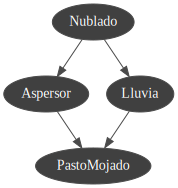

In [ ]:
# gnb.showBN dibuja el grafo de la red bayesiana
gnb.showBN(bn, size="6")


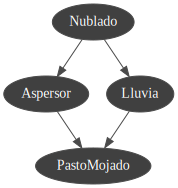

In [ ]:
# También podemos inspeccionar visualmente cada CPT
gnb.showBN(bn, size="6")
gnb.flow.row(
    bn.cpt("Nublado"),
    bn.cpt("Aspersor"),
    bn.cpt("Lluvia"),
    bn.cpt("PastoMojado"),
)


## 3. Inferencia probabilística

Una vez definida la red, podemos calcular cualquier probabilidad marginal o condicional usando un algoritmo de inferencia exacta como `LazyPropagation`.

**Pregunta 1:** sin ninguna evidencia, ¿cuál es la probabilidad de que el pasto esté mojado?

### `LazyPropagation`

`LazyPropagation` es el algoritmo de **inferencia exacta** que usa `pyAgrum` por defecto para responder preguntas probabilísticas sobre una red bayesiana, como:

- ¿Cuál es la probabilidad marginal de una variable? → $P(X)$
- ¿Cómo cambia esa probabilidad si observamos evidencia sobre otras variables? → $P(X \mid \text{evidencia})$

**¿Por qué "Lazy" (perezoso)?**

Calcular la distribución conjunta completa de todas las variables y luego marginalizar sería extremadamente costoso (el tamaño crece exponencialmente con el número de variables). En cambio, `LazyPropagation` usa el algoritmo de **propagación en árbol de unión** (*junction tree*), que aprovecha la estructura del DAG para:

1. Agrupar las variables en "clusters" (cliques) según sus dependencias.
2. Propagar mensajes entre esos clusters, combinando únicamente las CPTs relevantes en cada paso.
3. Postergar ("ser perezoso" respecto a) los cálculos y las multiplicaciones de tablas hasta el momento en que realmente se necesitan, evitando trabajo innecesario.

Esto permite obtener resultados **exactos** (no aproximados) de forma mucho más eficiente que la fuerza bruta, aunque para redes muy grandes o muy densas el costo computacional puede seguir siendo alto —en esos casos existen alternativas aproximadas como `LoopyBeliefPropagation` o métodos de muestreo (`GibbsSampling`, `ImportanceSampling`, etc.).

**Uso típico en pyAgrum:**

```python
ie = gum.LazyPropagation(bn)      # se crea el motor de inferencia sobre la red bn
ie.setEvidence({"Var": "valor"})  # (opcional) se fija evidencia observada
ie.makeInference()                # se ejecuta la propagación de mensajes
ie.posterior("OtraVar")           # se consulta la distribución posterior deseada
```

Cada vez que cambias la evidencia (`setEvidence`), es necesario volver a llamar `makeInference()` antes de consultar nuevas posteriores.

In [ ]:
ie = gum.LazyPropagation(bn)
ie.makeInference()

print("P(PastoMojado) sin evidencia:")
print(ie.posterior("PastoMojado"))


P(PastoMojado) sin evidencia:

  PastoMojado      |
no       |si       |
---------|---------|
 0.3529  | 0.6471  |



**Pregunta 2:** si **observamos** que el pasto está mojado, ¿cómo cambian nuestras creencias sobre si llovió o si se activó el aspersor? Esto es *inferencia hacia atrás* (diagnóstico), algo que las redes bayesianas hacen de forma natural.

In [ ]:
ie2 = gum.LazyPropagation(bn)
ie2.setEvidence({"PastoMojado": "si"})
ie2.makeInference()

print("P(Lluvia | PastoMojado = si):")
print(ie2.posterior("Lluvia"))
print()
print("P(Aspersor | PastoMojado = si):")
print(ie2.posterior("Aspersor"))


P(Lluvia | PastoMojado = si):

  Lluvia           |
no       |si       |
---------|---------|
 0.2921  | 0.7079  |


P(Aspersor | PastoMojado = si):

  Aspersor         |
no       |si       |
---------|---------|
 0.5702  | 0.4298  |



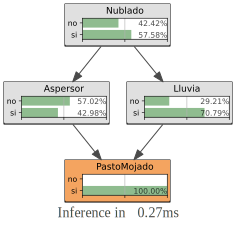

In [ ]:
# Visualización conjunta de la inferencia sobre toda la red dada la evidencia
gnb.showInference(bn, evs={"PastoMojado": "si"}, size="7")


## 4. De la inferencia probabilística a la inferencia **causal**

Hasta aquí solo hemos hecho *inferencia observacional*: calcular $P(\cdot \mid \text{evidencia})$. Pero surge una pregunta distinta y mucho más difícil:

> Si **forzáramos** el aspersor a activarse (independientemente de si está nublado o no), ¿qué probabilidad habría de que el pasto quedara mojado?

Esto ya **no** es $P(\text{PastoMojado} \mid \text{Aspersor} = \text{si})$, sino $P(\text{PastoMojado} \mid \operatorname{do}(\text{Aspersor} = \text{si}))$, en la notación del operador $\operatorname{do}(\cdot)$ de Judea Pearl.

**¿Por qué son distintas?** Porque `Nublado` es una **causa común** (confounder) de `Aspersor` y de `Lluvia`, y `Lluvia` también afecta a `PastoMojado`. Existe entonces un **camino de puerta trasera** (*backdoor path*):

```
Aspersor ← Nublado → Lluvia → PastoMojado
```

Cuando solo *observamos* que el aspersor está activado, esa observación también nos da información indirecta sobre `Nublado` (y por lo tanto sobre `Lluvia`), lo cual contamina la asociación observada. Cuando *intervenimos* con $\operatorname{do}(\cdot)$, cortamos artificialmente los arcos que entran a `Aspersor`: fijamos su valor sin importar la causa, así que ya no fluye información hacia atrás por ese camino.

El módulo `pyagrum.causal` implementa el *do-calculus* de Pearl para responder este tipo de preguntas automáticamente, incluyendo el criterio de puerta trasera cuando el efecto es identificable.

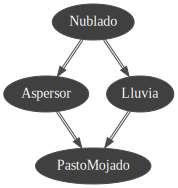

In [ ]:
# Un CausalModel se construye a partir de una BayesNet ya existente
cm = csl.CausalModel(bn)
cslnb.showCausalModel(cm, size="6")


In [ ]:
# Comparamos la cantidad OBSERVACIONAL con la cantidad CAUSAL (intervencionista)

# (a) Observacional: P(PastoMojado | Aspersor = si)
ie_obs = gum.LazyPropagation(bn)
ie_obs.setEvidence({"Aspersor": "si"})
ie_obs.makeInference()
p_obs = ie_obs.posterior("PastoMojado")

# (b) Causal: P(PastoMojado | do(Aspersor = si))
formula, p_do, explicacion = csl.causalImpact(
    cm, on="PastoMojado", doing="Aspersor", values={"Aspersor": "si"}
)

print("P(PastoMojado | Aspersor = si)   [observacional]:")
print(p_obs)
print()
print("P(PastoMojado | do(Aspersor = si)) [causal]:")
print(p_do)
print()
print("Método de identificación usado por pyAgrum:")
print(explicacion)


P(PastoMojado | Aspersor = si)   [observacional]:

  PastoMojado      |
no       |si       |
---------|---------|
 0.0730  | 0.9270  |


P(PastoMojado | do(Aspersor = si)) [causal]:

  PastoMojado      |
no       |si       |
---------|---------|
 0.0550  | 0.9450  |


Método de identificación usado por pyAgrum:
backdoor ['Nublado'] found.


In [ ]:
# cslnb.showCausalImpact ofrece una versión más visual: muestra el grafo causal,
# la fórmula de identificación en LaTeX y el resultado numérico en un solo paso
cslnb.showCausalImpact(cm, on="PastoMojado", doing="Aspersor", values={"Aspersor": "si"})


Observa que, aunque las dos cantidades pueden parecerse numéricamente en este ejemplo concreto (porque `Aspersor` no es una causa muy fuerte de `Lluvia` vía `Nublado`), **conceptualmente son preguntas distintas** y en redes con confusores más fuertes los valores pueden diverger de forma importante. `pyAgrum` nos muestra además la **fórmula de identificación** (ajuste por puerta trasera, en este caso) usada para pasar de la cantidad causal, no siempre observable directamente, a una expresión calculable con los datos observacionales disponibles.

Este mecanismo es la base para preguntas de política pública, medicina o negocio del tipo *"¿qué pasaría si...?"*, que no pueden responderse con correlación ni con inferencia bayesiana estándar sin este marco causal explícito.

## 5. Simulación de datos y aprendizaje de un DAG a partir de datos

Hasta ahora construimos la red **a mano**, conociendo de antemano su estructura. En la práctica, muchas veces solo tenemos una tabla de datos y queremos **aprender** qué estructura de dependencias la explica mejor.

Vamos a cambiar de contexto para no repetir el ejemplo anterior. Simularemos una base de datos pequeña sobre **hábitos de estudio y rendimiento académico**, con el siguiente DAG "verdadero" (que nosotros mismos definimos para poder comparar después contra lo que el algoritmo aprende):

```
Sueño ─┐
       ├─► Concentracion ─┐
Cafe ──┘                  ├─► Calificacion
                Estudio ──┘
```

- `Sueño` (bajo/alto) y `Cafe` (no/si) son causas de `Concentracion` (baja/alta).
- `Concentracion` y `Estudio` (poco/mucho) son causas de `Calificacion` (reprobado/aprobado).
- `Sueño`, `Cafe` y `Estudio` no tienen padres en este modelo simplificado (son variables "exógenas").

In [ ]:
n = 400  # base de datos pequeña, a propósito

def generar_concentracion(sueno, cafe):
    tabla = {
        ("alto", "si"): 0.85,
        ("alto", "no"): 0.70,
        ("bajo", "si"): 0.55,
        ("bajo", "no"): 0.20,
    }
    p_alta = tabla[(sueno, cafe)]
    return np.random.choice(["baja", "alta"], p=[1 - p_alta, p_alta])

def generar_calificacion(concentracion, estudio):
    tabla = {
        ("alta", "mucho"): 0.95,
        ("alta", "poco"): 0.70,
        ("baja", "mucho"): 0.60,
        ("baja", "poco"): 0.25,
    }
    p_aprob = tabla[(concentracion, estudio)]
    return np.random.choice(["reprobado", "aprobado"], p=[1 - p_aprob, p_aprob])

sueno = np.random.choice(["bajo", "alto"], size=n, p=[0.5, 0.5])
cafe = np.random.choice(["no", "si"], size=n, p=[0.6, 0.4])
estudio = np.random.choice(["poco", "mucho"], size=n, p=[0.5, 0.5])

concentracion = np.array([generar_concentracion(s, c) for s, c in zip(sueno, cafe)])
calificacion = np.array([generar_calificacion(cn, e) for cn, e in zip(concentracion, estudio)])

datos = pd.DataFrame({
    "Sueno": sueno,
    "Cafe": cafe,
    "Concentracion": concentracion,
    "Estudio": estudio,
    "Calificacion": calificacion,
})

datos.to_csv("datos_rendimiento.csv", index=False)
print(f"Base de datos simulada con {len(datos)} filas.")
datos.head(10)


Base de datos simulada con 400 filas.


,Sueno,Cafe,Concentracion,Estudio,Calificacion
0,bajo,no,baja,mucho,reprobado
1,alto,si,baja,poco,reprobado
2,alto,no,baja,mucho,reprobado
3,alto,si,alta,mucho,aprobado
4,bajo,no,baja,poco,reprobado
5,bajo,si,alta,mucho,aprobado
6,bajo,no,baja,mucho,reprobado
7,alto,no,alta,mucho,aprobado
8,alto,si,alta,poco,reprobado
9,alto,no,alta,poco,aprobado


### 5.1 Aprendiendo la estructura con `BNLearner`

`pyAgrum` incluye la clase `gum.BNLearner`, que puede leer directamente un archivo CSV e inferir tanto las variables (y sus dominios) como, opcionalmente, la estructura del DAG.

Usaremos un método **basado en score**: búsqueda voraz ascendente por colinas (*Greedy Hill Climbing*) optimizando el criterio **BIC** (*Bayesian Information Criterion*), que penaliza la complejidad del modelo para evitar sobreajuste.

$$ G^* \approx \arg\max_{G \,\in\, \mathcal{N}^*(G_0)} \left[ \sum_{j=1}^n \log P\big(\text{datos de } X_j \mid \text{padres}_G(X_j)\big) - \frac{d_G}{2}\log N \right]$$

donde $\mathcal {N}^*(G_0)$ representa el conjunto de grafos alcanzables desde $G_0$ (un grafo inicial),​ mediante la secuencia de pasos ascendentes de Hill Climbing (no todo $\mathcal G$), y el término $-\frac{d_G}{2}\log N$ es precisamente lo que "penaliza la complejidad del modelo para evitar sobreajuste".

Filename       : datos_rendimiento.csv
Size           : (400,5)
Variables      : Sueno[2], Cafe[2], Concentracion[2], Estudio[2], Calificacion[2]
Induced types  : True
Missing values : False
Algorithm      : Greedy Hill Climbing
Score          : BIC
Prior          : -



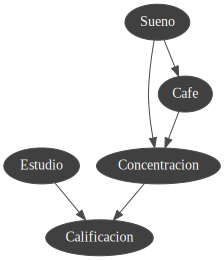

In [ ]:
learner = gum.BNLearner("datos_rendimiento.csv")
learner.useGreedyHillClimbing()
learner.useScoreBIC()

print(learner)

bn_aprendida = learner.learnBN()
gnb.showBN(bn_aprendida, size="6")


### 5.2 Comparando el DAG aprendido contra el DAG "verdadero"

In [ ]:
# Construimos a mano el DAG que usamos para simular los datos,
# solo con su estructura (sin necesidad de fijar las CPTs) para comparar

bn_verdadera = gum.BayesNet("RendimientoVerdadero")
for nombre, etiquetas in [
    ("Sueno", ["bajo", "alto"]),
    ("Cafe", ["no", "si"]),
    ("Concentracion", ["baja", "alta"]),
    ("Estudio", ["poco", "mucho"]),
    ("Calificacion", ["reprobado", "aprobado"]),
]:
    bn_verdadera.add(gum.LabelizedVariable(nombre, nombre, etiquetas))

for origen, destino in [
    ("Sueno", "Concentracion"),
    ("Cafe", "Concentracion"),
    ("Concentracion", "Calificacion"),
    ("Estudio", "Calificacion"),
]:
    bn_verdadera.addArc(origen, destino)

gnb.sideBySide(
    bn_verdadera,
    bn_aprendida,
    captions=["DAG verdadero (usado para simular)", "DAG aprendido con GHC + BIC"],
)


G <!-- Estudio --> Estudio Estudio <!-- Calificacion --> Calificacion Calificacion <!-- Estudio->Calificacion --> Estudio->Calificacion <!-- Concentracion --> Concentracion Concentracion <!-- Concentracion->Calificacion --> Concentracion->Calificacion <!-- Cafe --> Cafe Cafe <!-- Cafe->Concentracion --> Cafe->Concentracion <!-- Sueno --> Sueno Sueno <!-- Sueno->Concentracion --> Sueno->Concentracion DAG verdadero (usado para simular),G <!-- Estudio --> Estudio Estudio <!-- Calificacion --> Calificacion Calificacion <!-- Estudio->Calificacion --> Estudio->Calificacion <!-- Concentracion --> Concentracion Concentracion <!-- Concentracion->Calificacion --> Concentracion->Calificacion <!-- Cafe --> Cafe Cafe <!-- Cafe->Concentracion --> Cafe->Concentracion <!-- Sueno --> Sueno Sueno <!-- Sueno->Concentracion --> Sueno->Concentracion <!-- Sueno->Cafe --> Sueno->Cafe DAG aprendido con GHC + BIC


In [ ]:
# pyAgrum también ofrece una visualización de las diferencias entre dos redes:
# arcos correctos, faltantes, sobrantes o con dirección invertida
import pyagrum.lib.bn_vs_bn as bnvsbn

gnb.sideBySide(
    gnb.getBNDiff(bn_verdadera, bn_aprendida),
    bnvsbn.graphDiffLegend(),
    captions=["Diferencias estructurales", "Leyenda"],
)


G <!-- Sueno --> Sueno Sueno <!-- Cafe --> Cafe Cafe <!-- Sueno->Cafe --> Sueno->Cafe <!-- Concentracion --> Concentracion Concentracion <!-- Sueno->Concentracion --> Sueno->Concentracion <!-- Cafe->Concentracion --> Cafe->Concentracion <!-- Calificacion --> Calificacion Calificacion <!-- Concentracion->Calificacion --> Concentracion->Calificacion <!-- Estudio --> Estudio Estudio <!-- Estudio->Calificacion --> Estudio->Calificacion Diferencias estructurales,G <!-- a --> <!-- b --> <!-- a->b --> a->b overflow <!-- c --> <!-- d --> <!-- c->d --> c->d Missing <!-- e --> <!-- f --> <!-- e->f --> e->f reversed <!-- g --> <!-- h --> <!-- g->h --> g->h Correct Leyenda


### 5.3 Una advertencia importante: aprender un DAG ≠ aprender causalidad

Aunque el algoritmo haya recuperado (aproximadamente) el DAG correcto, hay dos límites fundamentales que conviene tener siempre presentes:

1. **Tamaño de muestra**: con solo 400 observaciones, es posible que algún arco no se detecte, aparezca invertido o se sume un arco espurio. Si vuelves a ejecutar este notebook aumentando `n` (por ejemplo a 5,000 o 50,000), normalmente verás que el DAG aprendido se acerca más al verdadero.

2. **Identificabilidad causal desde datos observacionales**: incluso con datos infinitos, muchos DAGs distintos pueden generar exactamente la misma distribución conjunta observacional (se dice que pertenecen a la misma **clase de equivalencia de Markov**, representada por un **grafo esencial** o CPDAG). En esos casos, el sentido de ciertos arcos **no puede determinarse solo con datos observacionales**: hace falta conocimiento experto, restricciones temporales (una causa no puede ocurrir después de su efecto) o, idealmente, datos experimentales/intervencionales.

`pyAgrum` permite visualizar esta clase de equivalencia con `gum.EssentialGraph`, donde los arcos no dirigidos (aristas) indican direcciones que los datos, por sí solos, no permiten distinguir.

In [ ]:
grafo_esencial = gum.EssentialGraph(bn_aprendida)

gnb.sideBySide(
    bn_aprendida,
    grafo_esencial,
    captions=["DAG aprendido (una orientación posible)", "Grafo esencial (clase de equivalencia de Markov)"],
)


G <!-- Estudio --> Estudio Estudio <!-- Calificacion --> Calificacion Calificacion <!-- Estudio->Calificacion --> Estudio->Calificacion <!-- Concentracion --> Concentracion Concentracion <!-- Concentracion->Calificacion --> Concentracion->Calificacion <!-- Cafe --> Cafe Cafe <!-- Cafe->Concentracion --> Cafe->Concentracion <!-- Sueno --> Sueno Sueno <!-- Sueno->Concentracion --> Sueno->Concentracion <!-- Sueno->Cafe --> Sueno->Cafe DAG aprendido (una orientación posible),no_name <!-- 0 --> 0 Sueno <!-- 1 --> 1 Cafe <!-- 0->1 --> 0->1 <!-- 2 --> 2 Concentracion <!-- 0->2 --> 0->2 <!-- 1->2 --> 1->2 <!-- 4 --> 4 Calificacion <!-- 2->4 --> 2->4 <!-- 3 --> 3 Estudio <!-- 3->4 --> 3->4 Grafo esencial (clase de equivalencia de Markov)


En este ejemplo le dimos a `BNLearner` una restricción implícita útil: como `Sueno`, `Cafe` y `Estudio` no tienen padres en la simulación, y el algoritmo de score suele favorecer estructuras simples, es probable que el grafo esencial recupere razonablemente bien las direcciones correctas. Pero en redes más complejas —o con menos guía experta— es común que el grafo esencial deje varias aristas sin orientar, y ahí es donde el **conocimiento de dominio** (o la posibilidad de diseñar experimentos, como en el enfoque de `pyagrum.causal` visto en la Sección 4) se vuelve indispensable para pasar de "estructura estadística" a "estructura causal".

## 6. Resumen

| Concepto | Herramienta en pyAgrum |
|---|---|
| Definir una red bayesiana | `gum.BayesNet`, `bn.add(...)`, `bn.addArc(...)` |
| Definir CPTs | `bn.cpt(nombre)[{"var": "valor"}] = [...]` |
| Inferencia exacta (observacional) | `gum.LazyPropagation` |
| Visualización | `pyagrum.lib.notebook` (`gnb.showBN`, `gnb.showInference`, ...) |
| Modelo causal e intervenciones `do(·)` | `pyagrum.causal.CausalModel`, `csl.causalImpact(...)` |
| Aprendizaje de estructura desde datos | `gum.BNLearner`, `useGreedyHillClimbing()`, `useScoreBIC()`, `learnBN()` |
| Clase de equivalencia de Markov | `gum.EssentialGraph` |

**Puntos clave para retener:**

- Una red bayesiana factoriza una distribución conjunta usando un DAG y CPTs locales.
- La inferencia bayesiana estándar responde preguntas del tipo "¿qué observo dado que observé otra cosa?" — es **asociacional**.
- El *do-calculus* responde preguntas del tipo "¿qué pasaría si yo interviniera?" — es **causal**, y en general **no** coincide con la inferencia observacional cuando hay confusores.
- Aprender un DAG a partir de datos observacionales tiene límites de identificabilidad (clases de equivalencia de Markov) y de tamaño muestral; el conocimiento de dominio sigue siendo necesario para afirmar causalidad con confianza.

### Referencias y para seguir explorando
- Tutorial oficial: <https://pyagrum.readthedocs.io/en/latest/notebooks/01-Tutorial_pyAgrum.html>
- Notebooks de causalidad de pyAgrum: <https://pyagrum.readthedocs.io/en/latest/notebooks.html#causal-bayesian-networks>
- Notebooks de aprendizaje de estructura: <https://pyagrum.readthedocs.io/en/latest/notebooks.html#learning-bayesian-networks>
- Pearl, J. (2018). *The Book of Why*.